# Assignment 1
## Markkus Phamuang Hansen - xfj774

In [148]:
import re
import pandas as pd
from cleantext import clean
import numpy as np
import matplotlib.pyplot as plt

## Part 1
### 1a

In [149]:
print(r'^(\d{2})(\d{2})(\d{2})-?(\d{4})')

^(\d{2})(\d{2})(\d{2})-?(\d{4})


### 1b

In [150]:
def cpr_to_century(cpr: str):
    def cpr_to_array(cpr: str):
        pattern = re.compile(r'^(\d{2})(\d{2})(\d{2})-?(\d{4})')
        m = pattern.match(cpr)
        if not m:
            raise ValueError("Invalid CPR format")
        return list(m.groups())
    cpr_ls = cpr_to_array(cpr)
    y, lst_dgts = int(cpr_ls[2]), int(cpr_ls[3])
    if lst_dgts in range(1, 4000):
        return 1900
    elif lst_dgts in range(4000, 4999):
        if y in range(0, 37):
            return 2000
        else:
            return 1900
    elif lst_dgts in range(5000, 9000):
        if y in range(0, 58):
            return 2000
        else:
            return 1800
    else:
        if y in range(0, 37):
            return 2000
        else:
            return 1900
# Example
print(cpr_to_century('191258-5024'))

1800


## Part 2

### 2.2

In [151]:
df = pd.read_csv('news_sample.csv')

### 2.3

In [152]:
display(df['type'])
display(df.loc[0, 'content'])
df['content']


0      unreliable
1            fake
2      unreliable
3      unreliable
4       clickbait
          ...    
245          fake
246          fake
247           NaN
248           NaN
249           NaN
Name: type, Length: 250, dtype: str

'Sometimes the power of Christmas will make you do wild and wonderful things. You do not need to believe in the Holy Trinity to believe in the positive power of doing good for others. The simple act of giving without receiving is lost on many of us these days, as worries about money and success hold us back from giving to others who are in need. One congregation in Ohio was moved to action by the power of a sermon given at their church on Christmas Eve. The pastor at Grand Lake United Methodist Church in Celina, Ohio gave an emotional sermon about the importance of understanding the message of Jesus.\n\nFor many religious people the message of Jesus is to help others before yourself, to make sure the people who are suffering get the help they need to enjoy life a little bit. The sermon was really about generosity and what that can look like in our lives. Jesus lived a long time ago and he acted generously in the fashion of his time – but what would a generous act look like in our times

0      Sometimes the power of Christmas will make you...
1      AWAKENING OF 12 STRANDS of DNA – “Reconnecting...
2      Never Hike Alone: A Friday the 13th Fan Film U...
3      When a rare shark was caught, scientists were ...
4      Donald Trump has the unnerving ability to abil...
                             ...                        
245    Prison for Rahm, God’s Work And Many Others\n\...
246    4 Useful Items for Your Tiny Home\n\nHeadline:...
247    Former CIA Director Michael Hayden said Thursd...
248    Antonio Sabato Jr. says Hollywood's liberal el...
249    Former U.S. President Bill Clinton on Monday c...
Name: content, Length: 250, dtype: str

### 2.4

In [153]:

def clean_text(texts): # parameter texts is a Pandas Series
    # Created month pattern with a raw string array for readability
    months = [r'january', r'february', r'march', r'april', r'may', r'june',
              r'july', r'august', r'september', r'october', r'november', r'december',
              r'jan', r'feb', r'mar', r'apr', r'jun', r'jul',
              r'aug', r'sep', r'oct', r'nov', r'dec']
    month_pattern = r'(' + '|'.join(months) + r')'
    ddmmyy_patt = r'(\d{1,2}-\d{1,2}-\d{2,4})|(\d{1,2}/\d{1,2}/\d{2,4})\W'
    m_d_y_patt = month_pattern + r'\s\d{1,2}(st|nd|rd|th)?,?\s\d{4}\W'
    d_m_y_patt = r'\s\d{1,2}(st|nd|rd|th)?\s(of\s)?' + month_pattern + r',?\s\d{4}\W'
    m_d_patt = month_pattern + r',?\s\d{1,2}(st|nd|rd|th)?\W'
    d_m_patt =  r'\s\d{1,2}(st|nd|rd|th)?\s(of\s)?' + month_pattern
    date_patts = [ddmmyy_patt, m_d_y_patt, d_m_y_patt, m_d_patt, d_m_patt]

    patterns = {
        'whitespace': re.compile(r'\s+'),
        'email': re.compile(r'\S+(?![^\w@])\w@\S+(?![^\.])\.\w{2,}(\.\w{2,})?'),
        'url': re.compile(r'(http\S+)|(\S+(?![^\w\.])\w\.\w{2,}(\.\w{2,})?(\S+)?)'),
        'clean_bef_date': r'[^\w\s<>/-]',
        'date': re.compile(r'(' + r')|('.join(date_patts) + r')'),
        'non_word_non_space': re.compile(r'[^\w\s<>]'),
        'num': re.compile(r'\d+')
    }


    cleaned = texts.copy()
    cleaned = cleaned.str.replace(pat=patterns['whitespace'], repl=r' ', regex=True)
    cleaned = cleaned.str.lower()
    cleaned = cleaned.str.replace(pat=patterns['email'], repl=r'<EMAIL>', regex=True)
    cleaned = cleaned.str.replace(pat=patterns['url'], repl=r'<URL>', regex=True)
    cleaned = cleaned.str.replace(pat=patterns['clean_bef_date'], repl=r'', regex=True)
    cleaned = cleaned.str.replace(pat=patterns['date'], repl=r'<DATE>', regex=True)
    cleaned = cleaned.str.replace(pat=patterns['non_word_non_space'], repl=r'', regex=True)
    cleaned = cleaned.str.replace(pat=patterns['whitespace'], repl=r' ', regex=True)
    cleaned = cleaned.str.replace(pat=patterns['num'], repl=r'<NUM>', regex=True)
    return cleaned

df['content'] = clean_text(df['content'])
# dictionary used for debugging
replaced = {
    'nums': sum([len(x) for x in df['content'].str.findall('<NUM>')]),
    'dates': sum([len(x) for x in df['content'].str.findall('<DATE>')]),
    'emails': sum([len(x) for x in df['content'].str.findall('<EMAIL>')]),
    'urls': sum([len(x) for x in df['content'].str.findall('<URL>')])
}
print(f'Tokens: {replaced}')
# examples
display(df.loc[175, 'content'])
display(df.loc[1, 'content'])
display(df.loc[69, 'content'])



Tokens: {'nums': 2011, 'dates': 189, 'emails': 8, 'urls': 480}


'trends global connected enterprise market <NUM> analysis by growth platform solution service vertical applications drivers opportunities and challenges of readers think this story is fact add your two cents headline bitcoin blockchain searches exceed trump blockchain stocks are next gobal connected enterprise market offers a professional and indepth study on the current state of the global embalming workstations industry along with geography platform solution service vertical industry trends and forecast to <NUM> the global connected enterprise market accounted for usd <NUM> billion in <NUM> growing at a cagr of <NUM> during the forecast period of <NUM> to <NUM> the upcoming market report contains data for historic year <NUM> <NUM> the base year of calculation is <NUM> and the forecast period is <NUM> to <NUM> connected enterprise helps in enabling more visibility faster decision making and new collaboration it is widely applicable in into banking financial services and insurance tele

'awakening of <NUM> strands of dna reconnecting with you movie of readers think this story is fact add your two cents headline bitcoin blockchain searches exceed trump blockchain stocks are next <DATE> <URL> as miles johnston was giving update it was another case of strange synchronicities of goodness hidden inside of tests and trials like a follow the whiterabbit down the rabbit hole type of exercise in researching the <NUM> strands of dna we came across some articles one in particular was as a strange synchronicity written exactly <NUM> year ago on the same topic <URL> <URL> what are the <NUM> strands of our dna and why is a war against our dna trailer for awakening of <NUM> strands the full video is only available as a paid video on vimeo awakening of <NUM> strands reconnecting with you <URL> awakening of <NUM> strands reconnecting with you from sandra daroy on vimeo we have not watched the full video but based on the strange synchronicities present within we suggest you use your di

'jim bray jim can be reached at jim publishes technofile magazine jim is an affiliate with the automobile journalists association of canada and his careers have included journalist technology retailer video store pioneer and syndicated columnist he does a biweekly column on cbc radio ones the business <URL> can be reached at email protected older articles by jim bray most recent articles by jim bray <DATE> jim bray who among us hasnt been found at one time or another to be in possession of sensitive documents it wouldnt be wise being caught with <DATE> jim bray take some world class cars from one of germanys top marques add a day on a road course race track learning and honing your driving skills and what do you have <DATE> jim bray it has just about everything you could ask for including the kitschy sync <DATE> jim bray is it a nifty way to add reality to the gaming experience or just another way for evil capitalists to make obscene profits off the backs of the downtrodden masses <DAT

### 2.5

In [154]:
months = [r'january', r'february', r'march', r'april', r'may', r'june',
          r'july', r'august', r'september', r'october', r'november', r'december',
          r'jan', r'feb', r'mar', r'apr', r'jun', r'jul',
          r'aug', r'sep', r'oct', r'nov', r'dec']
month_pattern = r'(' + '|'.join(months) + r')'
ddmmyy_patt = r'(\d{1,2}-\d{1,2}-\d{2,4})|(\d{1,2}/\d{1,2}/\d{2,4})\W'
m_d_y_patt = month_pattern + r'\s\d{1,2}(st|nd|rd|th)?,?\s\d{4}\W'
d_m_y_patt = r'\s\d{1,2}(st|nd|rd|th)?\s(of\s)?' + month_pattern + r',?\s\d{4}\W'
m_d_patt = month_pattern + r',?\s\d{1,2}(st|nd|rd|th)?\W'
d_m_patt =  r'\s\d{1,2}(st|nd|rd|th)?\s(of\s)?' + month_pattern
date_patt_arr = [ddmmyy_patt, m_d_y_patt, d_m_y_patt, m_d_patt, d_m_patt]
date_patts = re.compile(r'(' + r')|('.join(date_patt_arr) + r')')


df = pd.read_csv('news_sample.csv')
df['content'] = df['content'].str.lower()
df['content'] = df['content'].str.replace(pat=date_patts, repl='<DATE>', regex=True)
df['content'] = df['content'].apply(
    lambda x: clean(
        x,
        lower=False,
        no_line_breaks=True,
        no_urls=True,
        no_emails=True,
        no_numbers=True,
        no_punct=True,
        replace_with_number='<NUM>'
    )
)



replaced = {
    'nums': sum([len(x) for x in df['content'].str.findall('<NUM>')]),
    'dates': sum([len(x) for x in df['content'].str.findall('<DATE>')]),
    'emails': sum([len(x) for x in df['content'].str.findall('<EMAIL>')]),
    'urls': sum([len(x) for x in df['content'].str.findall('<URL>')])
}
'''
url seems to give vastly different number her than in prior task.
Unsure whether prior method overcounts, but there are places that cleantext
module undercounts, which can be directly seen in df.loc[1, 'content'].
Also, replaced['dates'] shows up different here because I didn't remove
characters like [ and ( before tokenizing dates in this sub-problem.
'''
print(f'Tokens: {replaced}')
# examples
display(df.loc[175, 'content'])
display(df.loc[1, 'content'])
display(df.loc[69, 'content'])


Tokens: {'nums': 2313, 'dates': 155, 'emails': 8, 'urls': 243}


'trends global connected enterprise market <NUM> analysis by growth platform solution service vertical applications drivers opportunities and challenges of readers think this story is fact add your two cents headline bitcoin blockchain searches exceed trump blockchain stocks are next gobal connected enterprise market offers a professional and indepth study on the current state of the global embalming workstations industry along with geography platform solution service vertical industry trends and forecast to <NUM> the global connected enterprise market accounted for usd <NUM> billion in <NUM> growing at a cagr of <NUM> during the forecast period of <NUM> to <NUM> the upcoming market report contains data for historic year <NUM> <NUM> the base year of calculation is <NUM> and the forecast period is <NUM> to <NUM> connected enterprise helps in enabling more visibility faster decision making and new collaboration it is widely applicable in into banking financial services and insurance tele

'awakening of <NUM> strands of dna reconnecting with you movie of readers think this story is fact add your two cents headline bitcoin blockchain searches exceed trump blockchain stocks are next <DATE> zurichtimesnet as miles johnston was giving update it was another case of strange synchronicities of goodness hidden inside of tests and trials like a follow the whiterabbit down the rabbit hole type of exercise in researching the <NUM> strands of dna we came across some articles one in particular was as a strange synchronicity written exactly <NUM> year ago on the same topic <URL> <URL> what are the <NUM> strands of our dna and why is a war against our dna trailer for awakening of <NUM> strands the full video is only available as a paid video on vimeo awakening of <NUM> strands reconnecting with you vimeocomondemandawakeningof<NUM>strands awakening of <NUM> strands reconnecting with you from sandra daroy on vimeo we have not watched the full video but based on the strange synchronicitie

'jim bray jim can be reached at jim publishes technofile magazine jim is an affiliate with the automobile journalists association of canada and his careers have included journalist technology retailer video store pioneer and syndicated columnist he does a biweekly column on cbc radio ones the business networkjim can be reached at email protected older articles by jim bray most recent articles by jim bray <DATE> jim bray who among us hasnt been found at one time or another to be in possession of sensitive documents it wouldnt be wise being caught with <DATE> jim bray take some world class cars from one of germanys top marques add a day on a road course race track learning and honing your driving skills and what do you have <DATE> jim bray it has just about everything you could ask for including the kitschy sync <DATE> jim bray is it a nifty way to add reality to the gaming experience or just another way for evil capitalists to make obscene profits off the backs of the downtrodden masses

## Part 3

### 3.1

In [155]:
# I will use my own clean_text function from task 2.4 due to sign of cleantext module undercounting url's
df = pd.read_csv('news_sample.csv')
words_bef = np.concatenate(df['content'].apply(lambda x: x.split(' ')))
unique_words_bef = np.unique(words_bef, return_counts=True)

df['content'] = clean_text(df['content'])
words_after = np.concatenate(df['content'].apply(lambda x: x.split(' ')))
unique_words_after = np.unique(words_after, return_counts=True)
print(f'Number of unique words before preprocessing: {len(unique_words_bef[0])}')
print(f'Number of unique words after preprocessing: {len(unique_words_after[0])}')

Number of unique words before preprocessing: 31303
Number of unique words after preprocessing: 16562


### 3.2

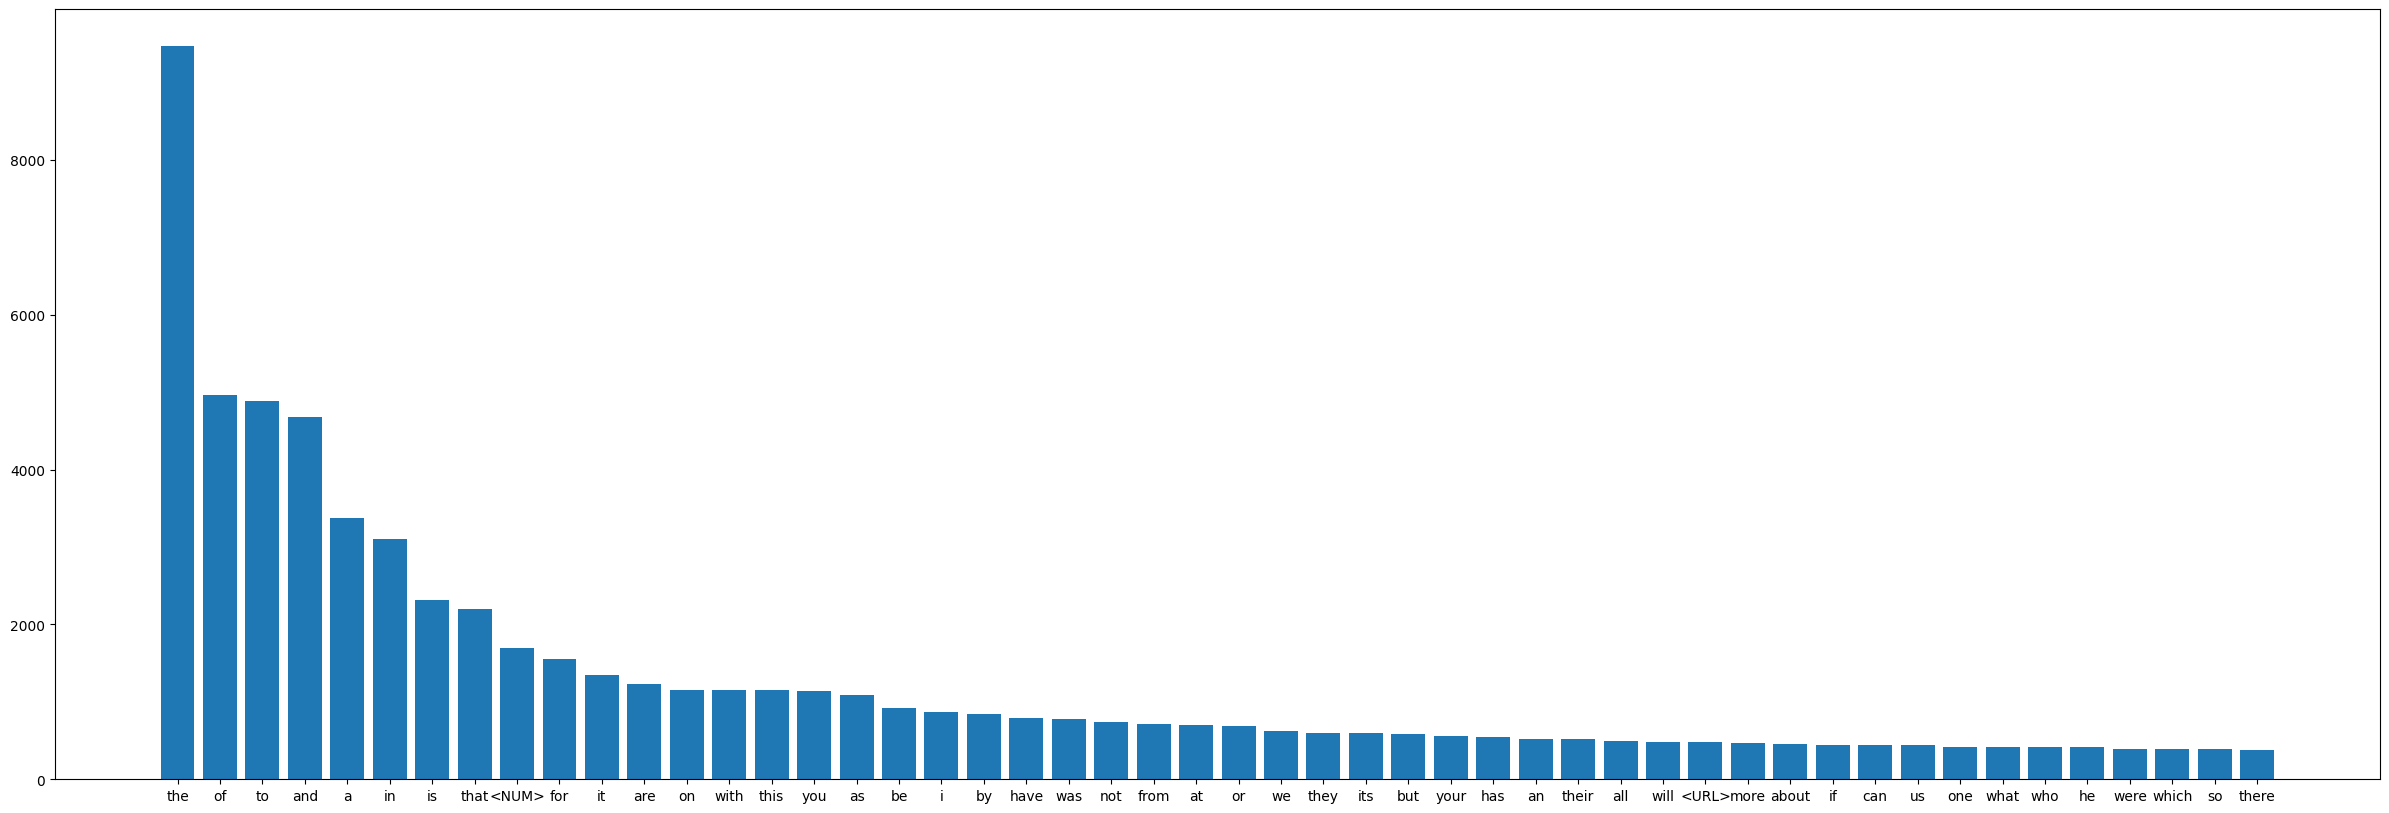

In [156]:
words_bef, counts_bef = unique_words_bef

idx = np.argsort(counts_bef)[::-1]

words_sorted_bef = words_bef[idx]
counts_sorted_bef = counts_bef[idx]

words_after, counts_after = unique_words_after

idx = np.argsort(counts_after)[::-1]

words_sorted_after = words_after[idx]
counts_sorted_after = counts_after[idx]

plt.figure(figsize=(30, 10))
plt.bar(words_sorted_after[:50], counts_sorted_after[:50])
plt.show()

## Part 4

### 4.1

In [301]:
from selenium import webdriver as wd
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException

### 4.2

In [158]:
driver = wd.Firefox()
driver.get('https://www.bbc.com/news/world/europe')
driver.quit()

### 4.3 

In [ ]:
def get_articles_on_page(driver, drop_duplicates: bool = True):
    wait = WebDriverWait(driver, 10)
    a_tags = pd.Series(
        wait.until(
            EC.visibility_of_all_elements_located((
                By.XPATH,
                '//a[contains(@href, "/articles/") '
                'and .//h2[@data-testid="card-headline"] '
                'and .//p[@data-testid="card-description"]]'
            ))
        )
    )
    article_df = pd.DataFrame(
        {
            'headline': a_tags.apply(
                lambda x: (x.find_element(By.XPATH, './/h2[@data-testid="card-headline"]')).text
            ),
            'summary': a_tags.apply(
                lambda x: (x.find_element(By.XPATH, './/p[@data-testid="card-description"]')).text
            ),
            'url': a_tags.apply(
                lambda x: x.get_attribute('href')
            )
        }
    )
    if drop_duplicates:
        article_df = article_df.drop_duplicates()
    return article_df

driver = wd.Firefox()
url = 'https://www.bbc.com/news/world/europe'
driver.get(url)
display(get_articles_on_page(driver))
driver.quit()

,headline,summary,url
0,Wave of arrests over killing of French nationa...,Eleven people are in detention in connection w...,https://www.bbc.com/news/articles/c62dzgy0q37o
1,Food prices are surging in Russia. Is the war ...,Russia's economy is hanging between stagnation...,https://www.bbc.com/news/articles/c1mjrgkk1m8o
2,Third Briton dies in French Alps avalanches in...,A total of 28 people have died in avalanches s...,https://www.bbc.com/news/articles/cy57nxrr6dqo
3,'Difficult' Russia-Ukraine peace talks end wit...,The second day of negotiations between Ukraine...,https://www.bbc.com/news/articles/c0k1xj0d708o
4,Spain luxury hotel scammer booked rooms for on...,Police arrest a 20-year-old suspected of defra...,https://www.bbc.com/news/articles/c0q3nwdk315o
5,Climber on trial for leaving girlfriend to die...,Kerstin G's boyfriend is accused of leaving he...,https://www.bbc.com/news/articles/c5yv9plyjgpo
6,Benfica claim 'defamation campaign' against Pr...,"Benfica claim there is a ""defamation campaign""...",https://www.bbc.com/sport/football/articles/cx...
7,Real Madrid tie halted over Vinicius racism al...,Real Madrid's Champions League knockout phase ...,https://www.bbc.com/sport/football/articles/cp...
8,Italian toddler in critical condition after tr...,Several people are under investigation after t...,https://www.bbc.com/news/articles/cpqw24v4dn9o
9,France releases suspected Russian 'shadow flee...,French Foreign Minister Jean-Noël Barrot said ...,https://www.bbc.com/news/articles/c8xy4dl2xwgo


### 4.4

In [423]:

def get_latest_news_on_page(driver):
    container = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.XPATH, '//div[@data-testid = "alaska"]'))
    )
    try:
        a_tags = WebDriverWait(container, 10).until(
            EC.presence_of_all_elements_located((By.XPATH, './/a[contains(@href, "/news/articles/")]'))
        )
        return [x.get_attribute('href') for x in a_tags]
    except TimeoutException:
        return []

def decline_signup(driver):
    try:
        WebDriverWait(driver, 1).until(
            EC.frame_to_be_available_and_switch_to_it((By.XPATH, '//iframe[contains(@id,"offer")]'))
        )
        register_present = True
    except TimeoutException:
        register_present = False
    finally:
        if register_present:
            close_button = WebDriverWait(driver, 10).until(
                EC.element_to_be_clickable((By.XPATH, '//button'))
            )
            close_button.click()
            # WebDriverWait(driver, 5).until(EC.staleness_of(close_button))
            driver.switch_to.default_content()
        return register_present

def decline_cookies(driver):
    try:
        WebDriverWait(driver, 1).until(
            EC.frame_to_be_available_and_switch_to_it((By.XPATH, '//iframe[contains(@id,"sp_message_iframe")]'))
        )
        cookies_present = True
    except TimeoutException:
        cookies_present = False
    finally:
        if cookies_present:
            please_go_away_cookies_youre_scaring_me_button = WebDriverWait(driver, 10).until(
                EC.element_to_be_clickable((By.XPATH, '//button[@title="I do not agree"]'))
            )
            please_go_away_cookies_youre_scaring_me_button.click()
            driver.switch_to.default_content()
        return cookies_present

def click_cookie_banner(driver):
    sure_ill_eat_cookies_button = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.ID, 'bbccookies-continue-button'))
    )
    sure_ill_eat_cookies_button.click()

def get_articles_on_region(driver):
    articles = []
    while True:
        articles += get_latest_news_on_page(driver)
        next_button = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.XPATH, '//div[@data-testid="pagination"]//button[@title="Next Page"]'))
        )
        if next_button.get_attribute('aria-disabled') == 'true':
            break
        next_button.click()
        WebDriverWait(driver, 10).until(EC.staleness_of(next_button))
    return articles



In [412]:
driver = wd.Firefox()
driver.get('https://www.bbc.com/news/world/europe')
decline_cookies(driver)
click_cookie_banner(driver)
europe = get_articles_on_region(driver)
europe_df = pd.DataFrame(data=europe, columns=['URL'])
display(europe_df)
driver.quit()

,URL
0,https://www.bbc.com/news/articles/c0k1xkllknmo
1,https://www.bbc.com/news/articles/cly034x149po
2,https://www.bbc.com/news/articles/ce8n4l8elpgo
3,https://www.bbc.com/news/articles/cn0ewjdgrkzo
4,https://www.bbc.com/news/articles/c78xjgq0nvqo
...,...
88,https://www.bbc.com/news/articles/cdx43rxgyk1o
89,https://www.bbc.com/news/articles/c5y2nddvmryo
90,https://www.bbc.com/news/articles/c7v0p818g91o
91,https://www.bbc.com/news/articles/crkryz35246o


### 4.5

In [413]:

def get_all_world_articles(driver):
    decline_cookies(driver)
    click_cookie_banner(driver)
    regions = ['us-canada', 'uk', 'africa', 'asia', 'australia', 'europe', 'latin_america', 'middle_east']
    articles = []
    for region in regions:
        url = 'https://www.bbc.com/news/' + region if region in regions[0:2] else 'https://www.bbc.com/news/world/' + region
        driver.get(url)
        decline_cookies(driver)
        decline_signup(driver)
        new_articles = get_articles_on_region(driver)
        articles += new_articles
    return articles



In [416]:

driver = wd.Firefox()
driver.get('https://www.bbc.com/news/world/europe')
world = get_all_world_articles(driver)
# I'm dropping duplicates for safety, even though I've yet to see any duplicates from get_all_world_articles
world_series = pd.Series(world).drop_duplicates()
display(world_series)
driver.quit()



0      https://www.bbc.com/news/articles/c78j01n775ko
1      https://www.bbc.com/news/articles/c4g57gqqln1o
2      https://www.bbc.com/news/articles/c39wj94me31o
3      https://www.bbc.com/news/articles/c4g02nxx2plo
4      https://www.bbc.com/news/articles/c86yj2vjp5go
                            ...                      
690    https://www.bbc.com/news/articles/cm2jek15m8no
691    https://www.bbc.com/news/articles/cx2p84xleg2o
692    https://www.bbc.com/news/articles/cj9rengvnp9o
693    https://www.bbc.com/news/articles/c4g49djqqjgo
694    https://www.bbc.com/news/articles/c23r4yeyxl9o
Length: 695, dtype: str

### 4.6

In [ ]:
world_series.to_csv('world_articles_links_only.csv', index=False)

## Part 5

## 5.1

In [ ]:
def scrape_article(driver):
    wait = WebDriverWait(driver, 10)
    headline = wait.until(
        EC.presence_of_element_located((By.TAG_NAME, 'h1'))
    ).text
    byline = wait.until(
        EC.presence_of_element_located((By.XPATH, '//div[@data-testid="byline"]'))
    )
    datetime_element = WebDriverWait(byline, 10).until(
        EC.presence_of_element_located((By.TAG_NAME, 'time'))
    )
    date: str = re.search(r'^[\d-]+', datetime_element.get_attribute('datetime')).group()
    try:
        author_elements = WebDriverWait(byline, 2).until(
            EC.presence_of_all_elements_located(
                (By.XPATH,
                '//span[@data-testid="byline-contributors"]//div[contains(@data-testid, "byline-contributors-contributor-")]//span[not(@data-testid)]')
            )
        )
        authors = [author.text for author in author_elements]
    except TimeoutException:
        authors = ['<NO_AUTHOR>']
    p_tags = wait.until(
        EC.presence_of_all_elements_located((By.XPATH, '//div[@data-component="text-block"]'))
    )
    content = p_tags[0].text
    for p in p_tags[1:]:
        content += '\n' + p.text
    article = {
        'headline': headline,
        'content': content,
        'date': date,
        'author': authors
    }
    return article

### 5.2

In [420]:
def scrape_articles_from_url(url_ls):
    driver = wd.Firefox()
    articles = {
        'headline': [],
        'content': [],
        'date': [],
        'author': []
    }
    cookies_declined = False
    cookie_banner_declined = False
    signup_declined = False
    for url in url_ls:
        driver.get(url)
        if not cookies_declined:
            cookies_declined = decline_cookies(driver)
        if not cookie_banner_declined:
            click_cookie_banner(driver)
            cookie_banner_declined = True
        if not signup_declined:
            signup_declined = decline_signup(driver)
        article = scrape_article(driver)
        articles['headline'].append(article['headline'])
        articles['content'].append(article['content'])
        articles['date'].append(article['date'])
        articles['author'].append(article['author'])
    driver.quit()
    return articles


In [421]:
article_urls: list[str] = np.concat(pd.read_csv('world_articles_links_only.csv').to_numpy())

In [ ]:
articles = scrape_articles_from_url(article_urls)
articles_df = pd.DataFrame(articles)
display(articles_df)

,headline,content,date,author
0,Grey's Anatomy star Eric Dane dies at 53 after...,"Eric Dane, the actor best known for his roles ...",2026-02-20,[Jessica Murphy]
1,Trump directs US government to prepare release...,US President Donald Trump says he will direct ...,2026-02-20,[Grace Eliza Goodwin]
2,New Mexico reopens criminal inquiry into Jeffr...,The US state of New Mexico will reopen a crimi...,2026-02-20,[Nardine Saad]
3,Two sisters among those killed in Lake Tahoe a...,The skiers who died in an avalanche in Califor...,2026-02-20,[Nardine Saad]
4,'Who's next?' - American lawmakers call for 'j...,Members of Congress have urged the US governme...,2026-02-19,[Ana Faguy and Helena Humphrey]
...,...,...,...,...
690,"Iran warns it will retaliate if US attacks, as...",Iran has warned it will retaliate if attacked ...,2026-01-12,"[Shayan Sardarizadeh,, Richard Irvine-Brown,, ..."
691,Last Kurdish forces leave Aleppo after ceasefi...,The final Kurdish fighters have withdrawn from...,2026-01-11,[Tabby Wilson]
692,'There wasn't even time for CPR': Iran medics ...,Staff at several hospitals in Iran have told t...,2026-01-10,"[Soroush Pakzad,, Roja Assadi,, and, Helen Sul..."
693,Iran leader says protesters are vandals trying...,Iran's Supreme Leader Ayatollah Ali Khamenei h...,2026-01-10,[Mallory Moench]


### 5.3

In [425]:
articles_df.to_csv('world_articles.csv')